# 01 — Exploratory Data Analysis: Beauty E-commerce Marketing Campaigns

**Data:** three public Kaggle campaign files (Nykaa, Purplle, Tira) — 166,665 campaigns, July 2024 to June 2025.
**Grain:** one row = one marketing campaign. There is **no customer or order identifier** in this data.

This notebook only *reads* data. The processed file used by Power BI is produced by the pipeline:
`python -m src.preprocessing` (same code that is called below, so the notebook and pipeline cannot drift apart).

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path("..").resolve()          # repo root (notebooks live in notebooks/)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
from src.preprocessing import build
from src.data_quality.kpis import compute_kpis

df = build(ROOT)                     # raw -> unioned, platform added, dd-mm-yyyy dates parsed, derived metrics
df["date"] = pd.to_datetime(df["date"])
df["spend"] = df["acquisition_cost"] * df["conversions"]     # acquisition_cost is a cost PER CONVERSION
df.shape

(166665, 22)

## 1. Structure and basic quality

In [3]:
print(df.dtypes.to_string())
print("\nnulls:", int(df.isna().sum().sum()),
      "| duplicate campaign_id:", int(df["campaign_id"].duplicated().sum()),
      "| date range:", df["date"].min().date(), "to", df["date"].max().date())
df["platform"].value_counts()

campaign_id                   str
campaign_type                 str
target_audience               str
duration                    int64
channel_used                  str
impressions                 int64
clicks                      int64
leads                       int64
conversions                 int64
revenue                     int64
acquisition_cost          float64
roi                       float64
language                      str
engagement_score          float64
customer_segment              str
date                datetime64[s]
CTR                       float64
Conversion_Rate           float64
CPL                       float64
CPCV                      float64
platform                      str
spend                     float64

nulls: 0 | duplicate campaign_id: 0 | date range: 2024-07-01 to 2025-06-24


platform
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
duration,"166,665.0000",17.4904,5.0000,11.0000,17.0000,24.0000,30.0000,7.5048
impressions,"166,665.0000","55,060.8541","10,001.0000","32,566.0000","55,110.0000","77,574.0000","100,000.0000","25,970.6540"
clicks,"166,665.0000","4,682.3675",202.0000,"2,109.0000","3,904.0000","6,688.0000","14,944.0000","3,176.5023"
leads,"166,665.0000","1,871.5142",48.0000,779.0000,"1,476.0000","2,598.0000","8,876.0000","1,429.5910"
conversions,"166,665.0000","1,029.0889",17.0000,401.0000,776.0000,"1,404.0000","6,686.0000",858.0112
revenue,"166,665.0000","513,906.6155","3,895.0000","177,661.0000","359,250.0000","684,797.0000","4,579,910.0000","487,644.2517"
acquisition_cost,"166,665.0000",376.0949,8.1800,106.7300,208.5100,427.5700,"15,473.1600",534.9396
roi,"166,665.0000",2.6906,-0.9900,0.0400,1.2300,3.5800,79.3000,4.4812
engagement_score,"166,665.0000",13.7663,2.5600,8.3800,13.5900,18.7900,30.9900,6.3300
date,166665,2024-12-20 16:12:39,2024-07-01 00:00:00,2024-09-25 00:00:00,2024-12-21 00:00:00,2025-03-17 00:00:00,2025-06-24 00:00:00,NaN


## 2. Headline KPIs
Rates are **ratios of sums** (e.g. CTR = total clicks / total impressions), not averages of row-level ratios.
Definitions live in `src/data_quality/kpis.py` and `docs/kpi_definitions.md`.

In [5]:
pd.Series(compute_kpis(df)).to_frame("value")

,value
campaign_rows,"166,665.0000"
total_revenue,"85,650,246,071.0000"
total_spend,"29,128,207,786.1300"
roi,1.9405
roas,2.9405
total_impressions,"9,176,717,247.0000"
total_clicks,"780,386,787.0000"
total_leads,"311,915,911.0000"
total_conversions,"171,513,099.0000"
ctr,0.0850


## 3. Distributions

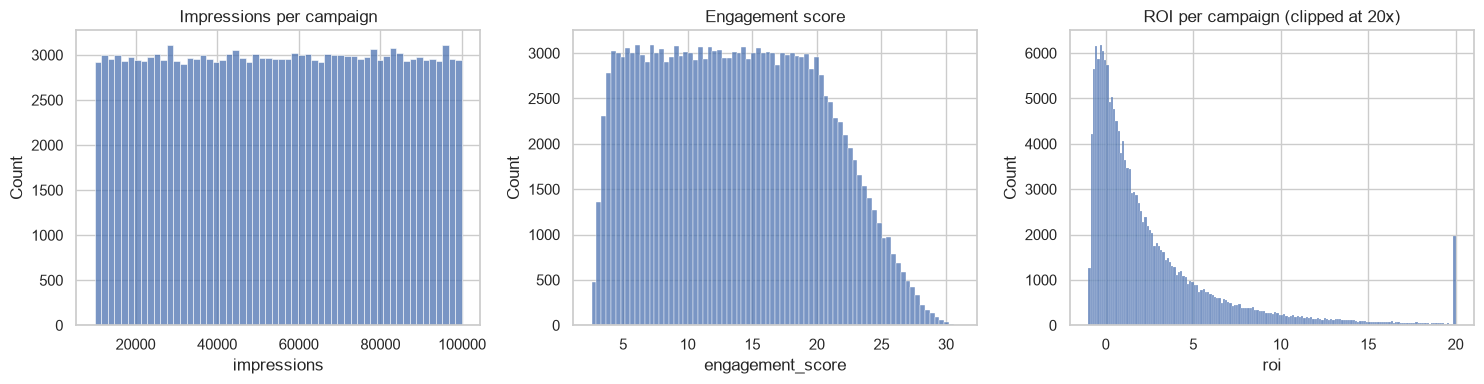

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["impressions"], ax=ax[0]).set_title("Impressions per campaign")
sns.histplot(df["engagement_score"], ax=ax[1]).set_title("Engagement score")
sns.histplot(df["roi"].clip(upper=20), ax=ax[2]).set_title("ROI per campaign (clipped at 20x)")
plt.tight_layout(); plt.show()

## 4. Performance by dimension (ratio of sums)

In [7]:
def perf(by):
    g = df.groupby(by).agg(campaigns=("campaign_id", "count"), revenue=("revenue", "sum"),
                           spend=("spend", "sum"), clicks=("clicks", "sum"),
                           impressions=("impressions", "sum"), conversions=("conversions", "sum"))
    g["roi"] = (g.revenue - g.spend) / g.spend
    g["ctr"] = g.clicks / g.impressions
    g["conversion_rate"] = g.conversions / g.clicks
    return g[["campaigns", "revenue", "roi", "ctr", "conversion_rate"]].sort_values("roi", ascending=False)

for dim in ["platform", "campaign_type", "customer_segment", "language"]:
    display(perf(dim))

,campaigns,revenue,roi,ctr,conversion_rate
platform,,,,,
Nykaa,55555,28656364282,1.9545,0.0851,0.2203
Purplle,55555,28540346627,1.9371,0.0850,0.2196
Tira,55555,28453535162,1.9297,0.0850,0.2194


,campaigns,revenue,roi,ctr,conversion_rate
campaign_type,,,,,
Paid Ads,33283,17238518867,1.9628,0.0850,0.2198
Social Media,33179,17102697975,1.9529,0.0853,0.2197
Email,33493,17222575561,1.9424,0.0850,0.2203
SEO,33207,17005702921,1.9296,0.0847,0.2198
Influencer,33503,17080750747,1.9147,0.0852,0.2193


,campaigns,revenue,roi,ctr,conversion_rate
customer_segment,,,,,
College Students,33533,17243247161,1.9501,0.0848,0.2205
Tier 2 City Customers,33091,17072782747,1.9493,0.0852,0.2198
Working Women,33413,17215043588,1.9475,0.0855,0.2191
Youth,33557,17225401651,1.9369,0.0848,0.2201
Premium Shoppers,33071,16893770924,1.9183,0.0849,0.2194


,campaigns,revenue,roi,ctr,conversion_rate
language,,,,,
Hindi,41745,21476573089,1.9489,0.0853,0.2201
English,41626,21418925404,1.9458,0.0849,0.2198
Tamil,41649,21447368164,1.9435,0.0853,0.2199
Bengali,41645,21307379414,1.9237,0.0847,0.2193


## 5. Channels — a multi-valued attribute
`channel_used` holds combinations such as `"WhatsApp, YouTube"` (156 distinct values). Exploding it naively counts a
campaign's revenue once per channel; an **equal-split** rule keeps attributed revenue equal to the true total.

In [8]:
ch = df[["campaign_id", "channel_used", "revenue", "spend"]].copy()
ch["channel"] = ch["channel_used"].str.split(",")
ch["n"] = ch["channel"].str.len()
ch = ch.explode("channel"); ch["channel"] = ch["channel"].str.strip()
att = ch.assign(rev=ch.revenue / ch.n, sp=ch.spend / ch.n).groupby("channel").agg(
    naive_revenue=("revenue", "sum"), attributed_revenue=("rev", "sum"), attributed_spend=("sp", "sum"))
att["attributed_roi"] = (att.attributed_revenue - att.attributed_spend) / att.attributed_spend
print("naive total:", f"{att.naive_revenue.sum():,.0f}", "| attributed total:", f"{att.attributed_revenue.sum():,.0f}",
      "| true total:", f"{df.revenue.sum():,.0f}")
att.sort_values("attributed_revenue", ascending=False)

naive total: 171,360,853,040 | attributed total: 85,650,246,071 | true total: 85,650,246,071


,naive_revenue,attributed_revenue,attributed_spend,attributed_roi
channel,,,,
Email,28701227780,"14,436,864,289.3333","4,869,082,185.8433",1.9650
Instagram,28759625581,"14,383,794,237.5000","4,855,031,634.7733",1.9627
Facebook,28527814614,"14,255,496,239.0000","4,866,539,035.8467",1.9293
WhatsApp,28469625887,"14,236,160,790.1667","4,846,417,505.6900",1.9375
YouTube,28471946681,"14,170,522,979.6667","4,851,535,970.7517",1.9208
Google,28430612497,"14,167,407,535.3333","4,839,601,453.2250",1.9274


## 6. Monthly trend
The data covers under 12 months, so year-over-year comparison is not possible. June 2025 is partial.

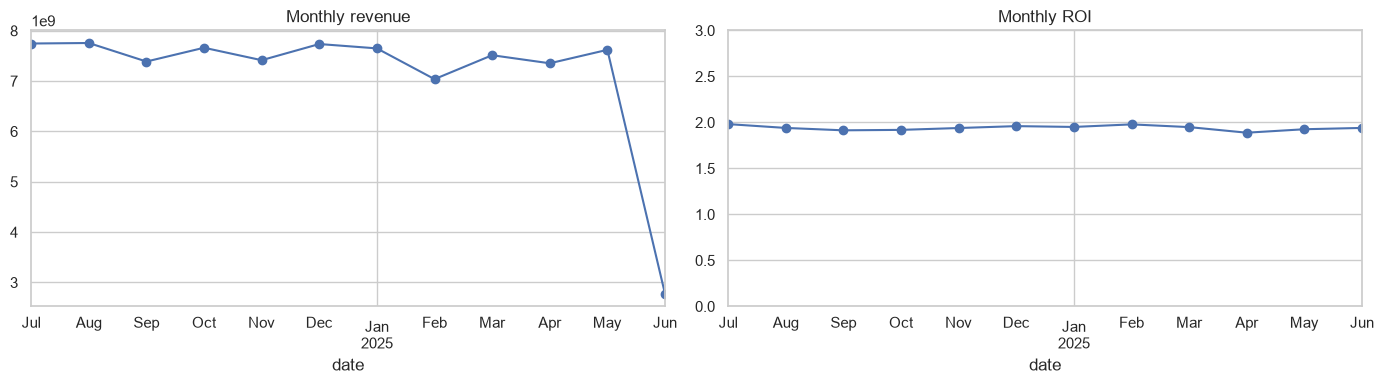

In [9]:
m = df.set_index("date").resample("MS").agg({"revenue": "sum", "spend": "sum", "campaign_id": "count"})
m["roi"] = (m.revenue - m.spend) / m.spend
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
m["revenue"].plot(ax=ax[0], marker="o", title="Monthly revenue")
m["roi"].plot(ax=ax[1], marker="o", title="Monthly ROI"); ax[1].set_ylim(0, 3)
plt.tight_layout(); plt.show()

## 7. Correlations between numeric fields

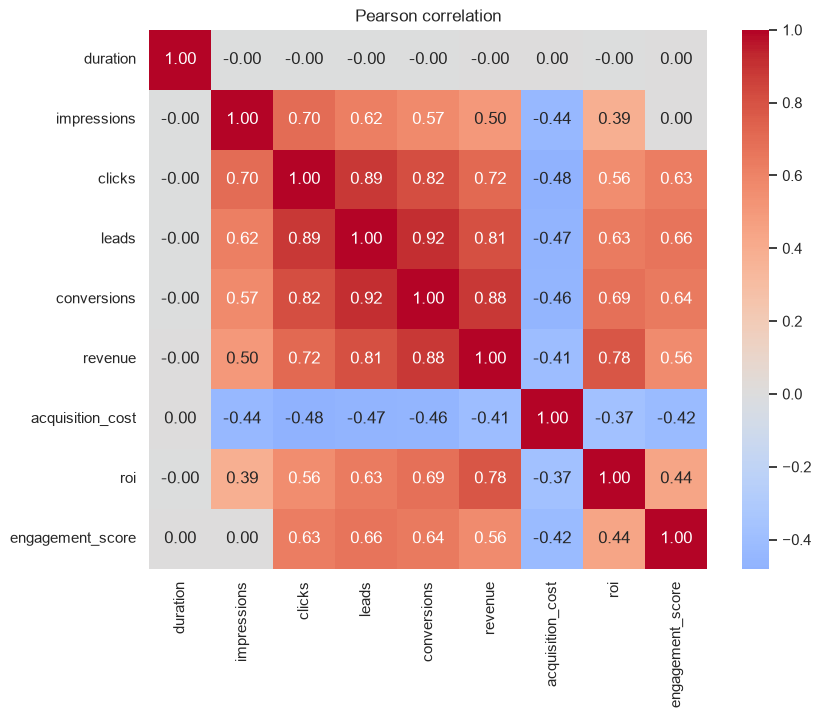

In [10]:
num = ["duration", "impressions", "clicks", "leads", "conversions", "revenue", "acquisition_cost", "roi", "engagement_score"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation"); plt.show()

## 8. Is there any real difference between groups?
One-way ANOVA (and Kruskal-Wallis, which does not assume normality) of campaign-level ROI across each dimension.
η² (eta squared) is the share of ROI variance explained by the grouping — the *practical* size of any difference.

In [11]:
from scipy import stats

rows = []
for dim in ["platform", "campaign_type", "customer_segment", "language", "target_audience"]:
    groups = [g["roi"].values for _, g in df.groupby(dim)]
    f, p = stats.f_oneway(*groups)
    h, p_kw = stats.kruskal(*groups)
    grand = df["roi"].mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    eta2 = ss_between / ((df["roi"] - grand) ** 2).sum()
    rows.append({"dimension": dim, "groups": len(groups), "anova_p": p, "kruskal_p": p_kw, "eta_squared": eta2})
signal = pd.DataFrame(rows)
signal

,dimension,groups,anova_p,kruskal_p,eta_squared
0,platform,3,0.3121,0.5925,0.0000
1,campaign_type,5,0.3472,0.1984,0.0000
2,customer_segment,5,0.4760,0.6913,0.0000
3,language,4,0.1609,0.8410,0.0000
4,target_audience,5,0.8155,0.8346,0.0000


In [12]:
mismatch = (df["target_audience"] != df["customer_segment"]).mean()
print(f"target_audience disagrees with customer_segment on {mismatch:.1%} of campaigns")

target_audience disagrees with customer_segment on 80.1% of campaigns


## Findings

* Funnel, duplicate, null and date checks are clean (the full 65-check framework is in `src/data_quality/`).
* Every brand, campaign type, segment and language delivers ROI of roughly 1.9–2.0x. The η² values above show that
  these groupings explain a negligible share of ROI variance, whatever their p-values.
* `target_audience` and `customer_segment` disagree on most rows, so audience-level conclusions are unreliable.
* **Business takeaway:** on this data there is no "winning" channel, brand or campaign type to shift budget toward.
  The honest recommendation is to test (see notebook 05), not to re-allocate on observational rankings.